## **Eye Retina Condition Image Recognition Model** 

Author: Cesar Hanna

<br/>

#### **Introduction**

In today’s fast paced technology, industries must keep up, especially the healthcare industry. That is not only vital from the business perspective, but also from the quality-of-life perspective, by improving people’s lives.

In this project, I am targeting the healthcare industry, particularly ophthalmology, the study that encompasses the diagnosis, treatment, and prevention of diseases and disorders related to the eye.

This project is by no means unique, rather it builds upon numerous studies and models created before that are used in the production systems of the healthcare industry.

#### **Objectives**

My approach is to create couple of models that predict the eye condition based on Optical Coherence Tomography (OCT) image(s). The conditions, or labels that exist in the dataset are as defined as follows:

- **AMD** (Age-related Macular Degeneration): A common eye condition that causes damage to the macula (central part of the retina), leading to blurred central vision. It's often associated with aging and comes in two forms: dry and wet.
- **CNV** (Choroidal Neovascularization): The abnormal growth of new, fragile blood vessels in the choroid layer beneath the retina. These vessels can leak fluid or blood, damaging the retina and causing vision loss, often seen in wet AMD.
- **DME** (Diabetic Macular Edema): A complication of diabetes where fluid leaks from damaged blood vessels in the retina, causing swelling in the macula. This leads to blurred or distorted central vision.
- **CSR** (Central Serous Retinopathy): A condition where fluid builds up under the macula, often associated with stress and corticosteroid use. This fluid can cause blurred vision, distortion, and blind spots.
- **DR** (Diabetic Retinopathy): Damage to the blood vessels in the retina caused by diabetes. It can lead to vision loss if untreated, progressing through stages from mild vessel changes to the growth of abnormal new vessels.
- **DRUSEN**: Tiny yellow deposits of fatty proteins and cellular debris that accumulate under the retina. They are common with aging, but their presence, size, and number can be an early sign of AMD.
- **NORMAL**: Refers to an eye with healthy vision and no significant detectable pathology. This implies proper light refraction, a clear lens, and a healthy retina and optic nerve.
- **MH** (Macular Hole): A small tear or defect in the macula, the central part of the retina responsible for sharp, detailed vision. It can cause distorted or blurred central vision and a blind spot.
  
The first model I created is based on Gaussian Naïve Bayes, using purely numpy and Python; no further libraries or packages were used to train and predict. The second model I created is a Convolutional Neural Network.


#### **Overview on the Datasets**

The datasets that I used are downloaded from Kaggle under this link: https://www.kaggle.com/datasets/obulisainaren/retinal-oct-c8/data

These datasets are produced using Optical Coherence Tomography (OCT) and are categorized as follows:
- 18400 training images, organized in 8 different folders representing the eye conditions; AMD, CNV, DME, CSR, DR, DRUSEN, NORMAL and MH.
- 2800 test images, organized in 8 different folders representing the eye conditions; AMD, CNV, DME, CSR, DR, DRUSEN, NORMAL and MH.
- 2800 validation images, organized in 8 different folders representing the eye conditions; AMD, CNV, DME, CSR, DR, DRUSEN, NORMAL and MH.

In my image processing, as you will see in the next section, I created from these folders and files, 3 dataframes, one for training, one for testing and one for validation. The training dataframe entailed 18400 records, the number of images downloaded, the test and validation dataframes entailed each 2800 records. All of these dataframes are built originally with 2 columns, Image and Labels.

The Image column contains the pixel representation of the image, from 0 to 255, and the Labels colmn contains obviously the eye condition.

#### **Image Processing**

In [40]:
# Importing the necessary libraries:
import numpy as np
from numpy import std, mean
from PIL import Image
import cv2
import os
import pandas as pd
import pickle
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Image Processing:
class Image_Processing():
    def __init__(self, image_path):
        self.image_path = image_path

    def image_to_array(self, image_array):
        self.image_array = image_array
        self.image_array = np.array(Image.open(self.image_path))
        return (self.image_array)

    def array_to_image(self, array_image):
        self.array_image = array_image
        return (Image.fromarray(self.array_image))

    def image_shape(self, image_shape):
        self.image_shape = image_shape
        self.image_shape = self.image_array.shape
        return (self.image_shape)

    def image_resize(self, size, image):
        self.image = image
        self.size = size
        self.image = self.image.resize(self.size, Image.LANCZOS)
        return (self.image)
    
    def image_normalize_flattened_df(self, flattened_images):
        self.flattened_images = flattened_images

        norm_images_df = pd.DataFrame()

        for i, col in enumerate(self.flattened_images.iloc[:, 0:-1]):
            # Initialize a list that will hold the normalized arrays:
            normalized_list = []
            
            for arr in self.flattened_images[col]:
                col_mean = np.mean(arr)
                col_std = np.std(arr)
                
                # Handle the case where standard deviation is zero by setting the std to 0:
                if col_std == 0:
                    normalized_values = [0] * len(arr)
                else:
                    normalized_values = [(scalar - col_mean) / col_std for scalar in arr]
                    
                normalized_list.append(normalized_values)
            
            # Assign the complete normalized list to the specific column:
            norm_images_df[col] = normalized_list
                        
        # Adding the labels column:
        norm_images_df['Label'] = self.flattened_images['Label'].values
        
        return norm_images_df

    def image_normalize_transformed_df(self, transformed_images):
        self.transformed_images = transformed_images.copy()

        norm_images_df = pd.DataFrame()
        
        for i, col in enumerate(self.transformed_images.iloc[:, 0:-1]):
            col_mean = mean(self.transformed_images[col])
            col_std = std(self.transformed_images[col])

            # Initialize a list that will hold the normalized arrays:
            normalized_list = []
            
            for j in self.transformed_images[col]:
                # Append the list with the normalized array:
                normalized_list.append((j - col_mean) / col_std)
                
            # Assign the complete normalized list to the dataframe column:    
            norm_images_df[col] = normalized_list

        # Add the Label column: 
        norm_images_df['Label'] = self.transformed_images['Label'].values
        
        return norm_images_df

    def image_normalize_original_df(self, original_images):
        self.original_images = original_images

        norm_images_df = pd.DataFrame()
        
        for i, col in enumerate(self.original_images.iloc[:, 0:-1]):
            normalized_list = []
            
            for j in self.original_images[col]:
                col_mean = np.mean(j)
                col_std = np.std(j)
                # Handle the case where standard deviation is zero by setting all values to 0 if std is 0:
                if col_std == 0:
                    normalized_values = [0] * len(arr)
                else:
                    # Normalize each value in j and append the normalized_list:
                    normalized_values = [(k - col_mean) / col_std for k in j]
                    normalized_list.append(normalized_values)
            
            # Assign the complete normalized list to the dataframe column:
            norm_images_df[col] = normalized_list
        
        # Add the Label column:
        norm_images_df['Label'] = self.original_images['Label'].values

        return norm_images_df
    
    def label_to_numeric(self, dataframe):
        for i in range(0, len(dataframe['Label'])):
            if dataframe.loc[i, 'Label'] == 'AMD':
                dataframe.loc[i, 'Label'] = 1
            elif dataframe.loc[i, 'Label'] == 'CNV':
                dataframe.loc[i, 'Label'] = 2
            elif dataframe.loc[i, 'Label'] == 'DME':
                dataframe.loc[i, 'Label'] = 3
            elif dataframe.loc[i, 'Label'] == 'CSR':
                dataframe.loc[i, 'Label'] = 4
            elif dataframe.loc[i, 'Label'] == 'DR':
                dataframe.loc[i, 'Label'] = 5
            elif dataframe.loc[i, 'Label'] == 'DRUSEN':
                dataframe.loc[i, 'Label'] = 6
            elif dataframe.loc[i, 'Label'] == 'NORMAL':
                dataframe.loc[i, 'Label'] = 7
            elif dataframe.loc[i, 'Label'] == 'MH':
                dataframe.loc[i, 'Label'] = 8
        return (dataframe)

#### **Image Dataframe Builder**

In [3]:
# Image Dataframe Builder:
class Image_Dataframe_Builder():
    def __init__(self):
        self.dataframe = pd.DataFrame(columns=['Image', 'Label'])

    # Inserting the image and label into the dataframe:
    def insert_image_to_dataframe(self, image_array, label):
        self.image_array = image_array
        self.label = label
        self.dataframe.loc[len(self.dataframe['Image'])] = [self.image_array, self.label]  
        return (self.dataframe)
    
    # Building the list of images:
    def image_list_builder(self, dataset):
        self.dataset = dataset
        self.files_list = []
        parent_folder_path = 'C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\archive\\RetinalOCT_Dataset\\RetinalOCT_Dataset\\grayscaled_images\\{}'.format(dataset)
        if os.path.exists(parent_folder_path):
            for folder in os.listdir(parent_folder_path):
                folder_path = os.path.join(parent_folder_path, folder)
                if os.path.isdir(folder_path):
                    for file in os.listdir(folder_path):
                        file_path = os.path.join(folder_path, file)
                        self.files_list.append(file_path)
            return self.files_list
        else:
            print(f"The path {parent_folder_path} does not exist.")

    # Building the dataframe of each list of images:
    def image_data_builder(self, image_list, label):
        self.image_list = image_list
        self.label = label
        for path in image_list:
            split_path = path.split("\\")
            if self.label in split_path:
                image = Image_Processing(path)
                image_array = image.image_to_array(image)
                image_data = self.insert_image_to_dataframe(image_array, self.label)
        return image_data
    
    # Calling the image_data_builder method to build the final dataframe by passing the list of images and labels:
    def final_images_dataframe(self, images, labels):
        self.images = images
        self.labels = labels
        for label in self.labels:
            images_df = self.image_data_builder(self.images, label)
        return images_df

In [4]:
# Resize the images:
def resize_images_in_folder(dataset):
    # Define the parent and destination folder paths:
    parent_folder_path = 'C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Original size images\\{}'.format(dataset)
    destination_folder_path = 'C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\archive\\RetinalOCT_Dataset\\RetinalOCT_Dataset\\{}'.format(dataset)

    # Create the folder path in the parent folder if it does not exist and loop through the folders:
    if os.path.exists(parent_folder_path):
        for folder in os.listdir(parent_folder_path):
            folder_path = os.path.join(parent_folder_path, folder)

            # Loop through the files in each folder, resizing each image and saving it to the destination folder:
            for file in os.listdir(folder_path):
                # Get the full path of the image file:
                img_path = os.path.join(folder_path, file)
                # Resize the image:
                Img_process = Image_Processing(img_path)
                img_pil = Image.open(Img_process.image_path)
                resized_image = Img_process.image_resize((80, 80), img_pil)
                # Create and save in the destination folder:
                save_folder = os.path.join(destination_folder_path, folder)
                if not os.path.exists(save_folder):
                    os.makedirs(save_folder, exist_ok=True)
                    save_path = os.path.join(save_folder, f"resized_{file}")
                    resized_image.save(save_path)

In [5]:
# Grayscale the images:
def grayscale_images_in_folder(dataset):
    # Define the parent and destination folder paths:
    parent_folder_path = 'C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\archive\\RetinalOCT_Dataset\\RetinalOCT_Dataset\\{}'.format(dataset)
    destination_folder_path = 'C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\archive\\RetinalOCT_Dataset\\RetinalOCT_Dataset\\grayscaled_images\\{}'.format(dataset)

    # Create the destination folder path if it does not exist
    os.makedirs(destination_folder_path, exist_ok=True)

    # Check if the parent folder exists and loop through the folders:
    if os.path.exists(parent_folder_path):
        for folder in os.listdir(parent_folder_path):
            folder_path = os.path.join(parent_folder_path, folder)

            # Ensure it's a directory or the directory exists, and create the directories where the destination files will be saved:
            if os.path.isdir(folder_path):
                # Create the subfolder in the destination for the current category
                save_folder = os.path.join(destination_folder_path, folder)
                os.makedirs(save_folder, exist_ok=True)

                # Loop through the files in each folder, grayscaling each image and saving it to the destination folder:
                for file in os.listdir(folder_path):
                    # Get the full path of the image file:
                    img_path = os.path.join(folder_path, file)

                    # Ensure it's a file which can be converted:
                    if os.path.isfile(img_path):
                        try:
                            # Grayscale the image:
                            img_pil = Image.open(img_path) # Use img_path directly
                            grayscaled_img = img_pil.convert('L')

                            # Define the save path for the grayscaled image:
                            save_path = os.path.join(save_folder, f"grayscaled_{file}")

                            # Save the grayscaled image:
                            grayscaled_img.save(save_path)
                        except Exception as e:
                            print(f"Error processing {img_path}: {e}")
    else:
        print(f"Parent folder does not exist: {parent_folder_path}")

In [5]:
# Resize the test images:
resize_images_in_folder('test')

# Resize the validation images:
resize_images_in_folder('val')

# Resize the training images:
resize_images_in_folder('train')

In [ ]:
# Grayscale the test images:
grayscale_images_in_folder('test')

# Grayscale the validation images:
grayscale_images_in_folder('val')

# Grayscale the training images:
grayscale_images_in_folder('train')

In [6]:
# Intializing the class object:
img_in_df = Image_Dataframe_Builder()

In [7]:
# Creating the list of images:
test_list = img_in_df.image_list_builder("test")
train_list = img_in_df.image_list_builder("train")
validation_list = img_in_df.image_list_builder("val")

In [8]:
# Creating the list of labels:
labels = ['AMD', 'CNV', 'DME', 'CSR', 'DR', 'DRUSEN', 'NORMAL', 'MH']

In [9]:
# Initializing the class object to build the test dataframe:
img_in_df = Image_Dataframe_Builder()
test_images = img_in_df.final_images_dataframe(test_list, labels)

# Initializing the class object to build the train dataframe:
img_in_df = Image_Dataframe_Builder()
train_images = img_in_df.final_images_dataframe(train_list, labels)

# Initializing the class object to build the validation dataframe:
img_in_df = Image_Dataframe_Builder()
validation_images = img_in_df.final_images_dataframe(validation_list, labels)

Storing the dataframes in pickle format:

In [10]:
# Train dataset to pickle:
train_images_short = train_images
train_images_short.to_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\train_images_short.pkl')

# Test dataset to pickle:
test_images_short = test_images
test_images_short.to_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\test_images_short.pkl')

# Validation dataset to pickle:
validation_images_short = validation_images
validation_images_short.to_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\validation_images_short.pkl')

#### **Method 1: Preparing the dataframes for training using flattened image arrays**

**Flatten the dataframes**

In [25]:
# Flatten the training dataframe:
train_images_short.loc[:, "Image"] = train_images_short.loc[:, "Image"].to_numpy()
train_images_short.loc[:, "Image"] = train_images_short.loc[:, "Image"].apply(lambda x: x.flatten() if isinstance(x, np.ndarray) else x)
train_images_flattened = train_images_short
train_images_flattened

,Image,Label
0,"[73, 74, 76, 79, 82, 85, 87, 89, 88, 90, 93, 9...",AMD
1,"[94, 94, 96, 96, 96, 94, 93, 92, 86, 86, 87, 8...",AMD
2,"[102, 100, 97, 90, 79, 72, 77, 86, 100, 102, 1...",AMD
3,"[103, 104, 103, 99, 96, 97, 101, 105, 102, 101...",AMD
4,"[83, 89, 90, 84, 79, 77, 72, 66, 67, 67, 67, 7...",AMD
...,...,...
18395,"[31, 31, 31, 28, 26, 24, 25, 27, 30, 30, 30, 2...",MH
18396,"[97, 105, 106, 92, 73, 56, 40, 27, 47, 27, 40,...",MH
18397,"[28, 28, 28, 28, 28, 28, 28, 28, 26, 28, 31, 3...",MH
18398,"[4, 4, 3, 3, 2, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, ...",MH


In [26]:
# Flatten the test dataframe:
test_images_short.loc[:, "Image"] = test_images_short.loc[:, "Image"].to_numpy()
test_images_short.loc[:, "Image"] = test_images_short.loc[:, "Image"].apply(lambda x: x.flatten() if isinstance(x, np.ndarray) else x)
test_images_flattened = test_images_short
test_images_flattened

,Image,Label
0,"[77, 79, 82, 87, 92, 98, 102, 105, 101, 100, 9...",AMD
1,"[171, 171, 170, 168, 167, 165, 164, 163, 161, ...",AMD
2,"[120, 123, 123, 121, 122, 127, 129, 127, 129, ...",AMD
3,"[115, 117, 121, 125, 129, 133, 135, 136, 134, ...",AMD
4,"[82, 76, 71, 72, 80, 90, 97, 99, 107, 109, 110...",AMD
...,...,...
2795,"[30, 30, 30, 30, 30, 30, 30, 30, 31, 31, 31, 3...",MH
2796,"[36, 36, 37, 38, 40, 41, 42, 42, 40, 39, 39, 3...",MH
2797,"[19, 19, 19, 19, 19, 19, 19, 19, 20, 19, 19, 1...",MH
2798,"[41, 41, 42, 42, 43, 43, 44, 44, 43, 44, 45, 4...",MH


In [27]:
# Flatten the validation dataframe:
validation_images_short.loc[:, "Image"] = validation_images_short.loc[:, "Image"].to_numpy()
validation_images_short.loc[:, "Image"] = validation_images_short.loc[:, "Image"].apply(lambda x: x.flatten() if isinstance(x, np.ndarray) else x)
validation_images_flattened = validation_images_short
validation_images_flattened

,Image,Label
0,"[127, 124, 121, 119, 118, 119, 120, 122, 118, ...",AMD
1,"[169, 172, 174, 173, 170, 168, 168, 170, 171, ...",AMD
2,"[149, 149, 148, 147, 144, 140, 136, 134, 127, ...",AMD
3,"[90, 89, 89, 88, 87, 86, 85, 85, 78, 76, 74, 7...",AMD
4,"[87, 90, 93, 96, 98, 98, 97, 95, 98, 98, 98, 9...",AMD
...,...,...
2795,"[41, 26, 20, 30, 38, 33, 29, 30, 21, 26, 31, 3...",MH
2796,"[18, 19, 19, 20, 20, 21, 21, 21, 20, 20, 20, 2...",MH
2797,"[19, 19, 19, 18, 18, 17, 17, 17, 17, 18, 18, 1...",MH
2798,"[41, 44, 47, 47, 45, 43, 42, 42, 43, 43, 43, 4...",MH


**Pickle the dataframes**

In [28]:
# Pickle the training dataset:
train_images_flattened.to_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\archive\\RetinalOCT_Dataset\\RetinalOCT_Dataset\\grayscaled_images\\train_images_grayscaled_flattened.pkl')

In [29]:
# Pickle the test dataset:
test_images_flattened.to_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\archive\\RetinalOCT_Dataset\\RetinalOCT_Dataset\\grayscaled_images\\test_images_grayscaled_flattened.pkl')

In [30]:
# Pickle the validation dataset:
validation_images_flattened.to_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\archive\\RetinalOCT_Dataset\\RetinalOCT_Dataset\\grayscaled_images\\validation_images_grayscaled_flattened.pkl')

**Normalizing the grayscaled images**

In [31]:
# Normalize the test images:
image_process = Image_Processing('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\archive\\RetinalOCT_Dataset\\RetinalOCT_Dataset\\grayscaled_images\\test_images_grayscaled_flattened.pkl')
normalized_test_images = image_process.image_normalize_flattened_df(test_images_flattened)
normalized_test_images

,Image,Label
0,"[-0.37123666446183173, -0.31815901880457637, -...",AMD
1,"[2.159761351065201, 2.159761351065201, 2.13283...",AMD
2,"[0.7211321794028388, 0.7992150790285713, 0.799...",AMD
3,"[0.7145484547633246, 0.7689831134447506, 0.877...",AMD
4,"[-0.1680406698713275, -0.3604766033992704, -0....",AMD
...,...,...
2795,"[-0.5753230452358062, -0.5753230452358062, -0....",MH
2796,"[-0.624539271216585, -0.624539271216585, -0.59...",MH
2797,"[-0.6752405763553014, -0.6752405763553014, -0....",MH
2798,"[-0.697223101802175, -0.697223101802175, -0.65...",MH


In [32]:
# Normalize the training images:
image_process = Image_Processing('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\archive\\RetinalOCT_Dataset\\RetinalOCT_Dataset\\grayscaled_images\\train_images_grayscaled_flattened.pkl')
normalized_train_images = image_process.image_normalize_flattened_df(train_images_flattened)
normalized_train_images

,Image,Label
0,"[-0.4757771620398047, -0.44945227086710715, -0...",AMD
1,"[0.2173437655485226, 0.2173437655485226, 0.280...",AMD
2,"[0.6899043812332816, 0.6141726343267244, 0.500...",AMD
3,"[0.4347936654365096, 0.4646587521957654, 0.434...",AMD
4,"[-0.1670329154813622, 0.013152604491790142, 0....",AMD
...,...,...
18395,"[-0.4987700273691234, -0.4987700273691234, -0....",MH
18396,"[1.620292662420826, 1.9042626231107225, 1.9397...",MH
18397,"[-0.6507148274938899, -0.6507148274938899, -0....",MH
18398,"[-1.3435171604916718, -1.3435171604916718, -1....",MH


In [33]:
# Normalize the validation images:
image_process = Image_Processing('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\archive\\RetinalOCT_Dataset\\RetinalOCT_Dataset\\grayscaled_images\\validation_images_grayscaled_flattened.pkl')
normalized_validation_images = image_process.image_normalize_flattened_df(validation_images_flattened)
normalized_validation_images

,Image,Label
0,"[1.657163806961228, 1.5356546201516226, 1.4141...",AMD
1,"[3.517547355743547, 3.640081295842276, 3.72177...",AMD
2,"[2.3812321119223885, 2.3812321119223885, 2.344...",AMD
3,"[0.052468601886860464, 0.021216945109205042, 0...",AMD
4,"[0.02935118047107902, 0.13305796461622363, 0.2...",AMD
...,...,...
2795,"[-0.1339189634344836, -0.8813301889277926, -1....",MH
2796,"[-1.3279257543775738, -1.2881678702446762, -1....",MH
2797,"[-0.6171101858678707, -0.6171101858678707, -0....",MH
2798,"[-0.6363149970619771, -0.5329148198067619, -0....",MH


**Converting the labels to numeric**

In [34]:
# Converting label to numeric for the train dataset:
normalized_train_images_final = image_process.label_to_numeric(normalized_train_images)
normalized_train_images_final

,Image,Label
0,"[-0.4757771620398047, -0.44945227086710715, -0...",1
1,"[0.2173437655485226, 0.2173437655485226, 0.280...",1
2,"[0.6899043812332816, 0.6141726343267244, 0.500...",1
3,"[0.4347936654365096, 0.4646587521957654, 0.434...",1
4,"[-0.1670329154813622, 0.013152604491790142, 0....",1
...,...,...
18395,"[-0.4987700273691234, -0.4987700273691234, -0....",8
18396,"[1.620292662420826, 1.9042626231107225, 1.9397...",8
18397,"[-0.6507148274938899, -0.6507148274938899, -0....",8
18398,"[-1.3435171604916718, -1.3435171604916718, -1....",8


In [35]:
# Converting label to numeric for the test dataset:
normalized_test_images_final = image_process.label_to_numeric(normalized_test_images)
normalized_test_images_final

,Image,Label
0,"[-0.37123666446183173, -0.31815901880457637, -...",1
1,"[2.159761351065201, 2.159761351065201, 2.13283...",1
2,"[0.7211321794028388, 0.7992150790285713, 0.799...",1
3,"[0.7145484547633246, 0.7689831134447506, 0.877...",1
4,"[-0.1680406698713275, -0.3604766033992704, -0....",1
...,...,...
2795,"[-0.5753230452358062, -0.5753230452358062, -0....",8
2796,"[-0.624539271216585, -0.624539271216585, -0.59...",8
2797,"[-0.6752405763553014, -0.6752405763553014, -0....",8
2798,"[-0.697223101802175, -0.697223101802175, -0.65...",8


In [36]:
# Converting label to numeric for the validation dataset:
normalized_validation_images_final = image_process.label_to_numeric(normalized_validation_images)
normalized_validation_images_final

,Image,Label
0,"[1.657163806961228, 1.5356546201516226, 1.4141...",1
1,"[3.517547355743547, 3.640081295842276, 3.72177...",1
2,"[2.3812321119223885, 2.3812321119223885, 2.344...",1
3,"[0.052468601886860464, 0.021216945109205042, 0...",1
4,"[0.02935118047107902, 0.13305796461622363, 0.2...",1
...,...,...
2795,"[-0.1339189634344836, -0.8813301889277926, -1....",8
2796,"[-1.3279257543775738, -1.2881678702446762, -1....",8
2797,"[-0.6171101858678707, -0.6171101858678707, -0....",8
2798,"[-0.6363149970619771, -0.5329148198067619, -0....",8


#### **Mathod 2: Transforming the dataframes using statistical metrics**

**1. Understanding the distribution of data**

Since I am going to train my data on the training dataset, obviously, I will therefore analyze what is the distribution of data points in the "normalized_train_images_updated" dataframe.

As my dataset is large, I will analyze 5 samples each with 500 images.

***First sample images***

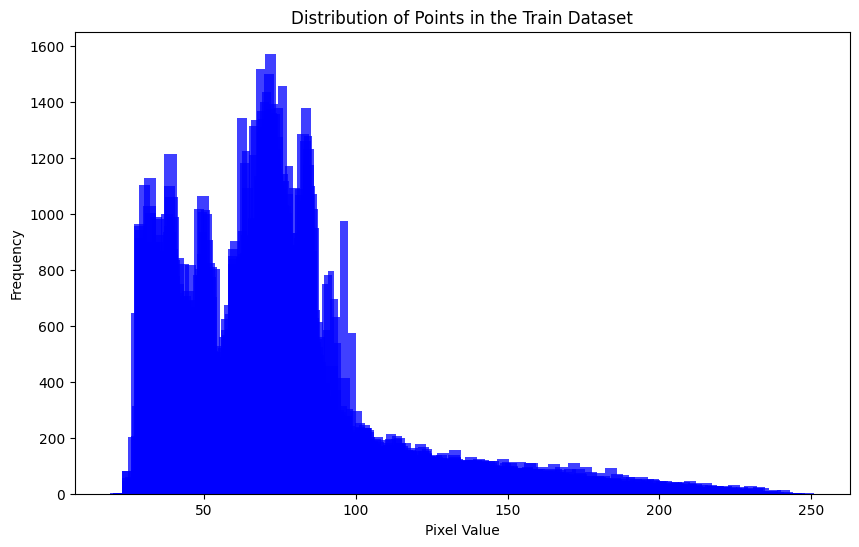

In [276]:
plt.figure(figsize=(10, 6))
plt.title('Distribution of Points in the Train Dataset')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(False)
for i in range(0, 500):
    plt.hist(train_images_flattened['Image'][i], bins=50, alpha=0.75, color='blue')
plt.show()

We see that between 0 and 50, the data is random, no clear shape. From 50 until 250 the data started to normalize, with some noise and skewness on the right. let's see how the next sample look like.

***Second sample images***

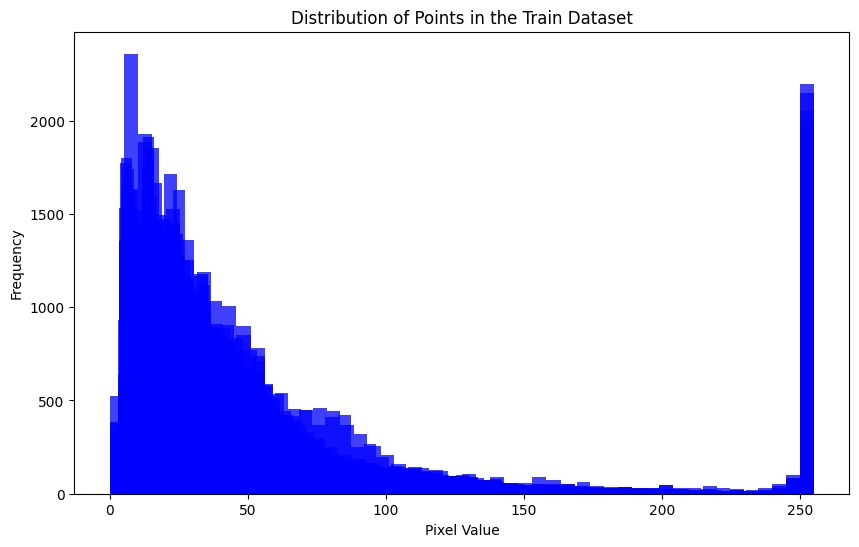

In [277]:
plt.figure(figsize=(10, 6))
plt.title('Distribution of Points in the Train Dataset')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(False)
for i in range(5000, 5500):
    plt.hist(train_images_flattened['Image'][i], bins=50, alpha=0.75, color='blue')
plt.show()

We see here that the data distribution can either be interpreted as taking a gamma distribution or normal distribution with skewness on the right side, but, whichever distribution we have, one thing is certain here that the data has significant noise on the last bin on the right.

***Third sample images***

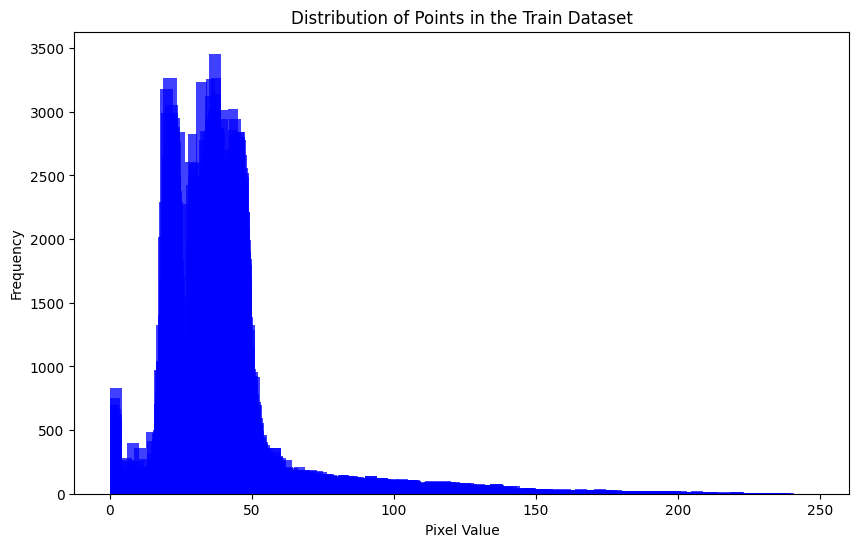

In [278]:
plt.figure(figsize=(10, 6))
plt.title('Distribution of Points in the Train Dataset')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(False)
for i in range(10000, 10500):
    plt.hist(train_images_flattened['Image'][i], bins=50, alpha=0.75, color='blue')
plt.show()

This sample clearly shows a normal distribution with skweness on the right and some noise in the first bin on the left.

***Fourth sample images***

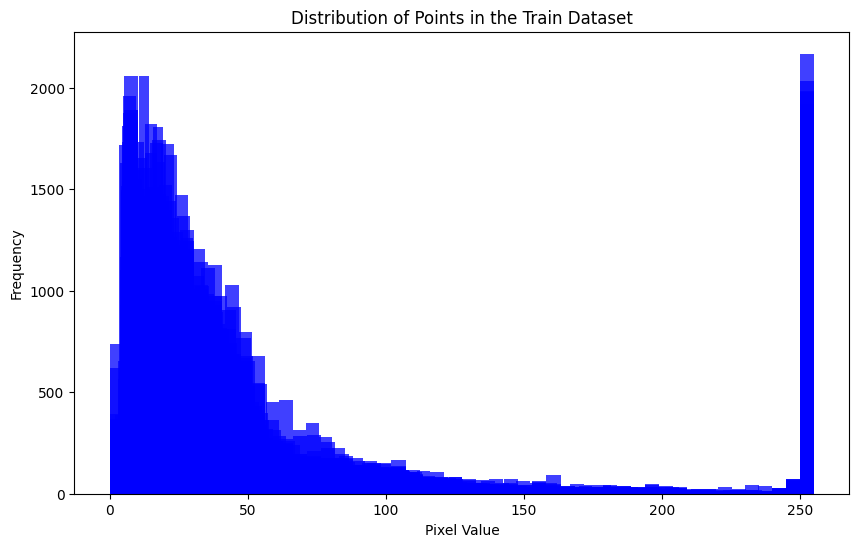

In [279]:
plt.figure(figsize=(10, 6))
plt.title('Distribution of Points in the Train Dataset')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(False)
for i in range(15000, 15500):
    plt.hist(train_images_flattened['Image'][i], bins=50, alpha=0.75, color='blue')
plt.show()

This fourth sample is very similar to the second sample.

***Fifth sample images***

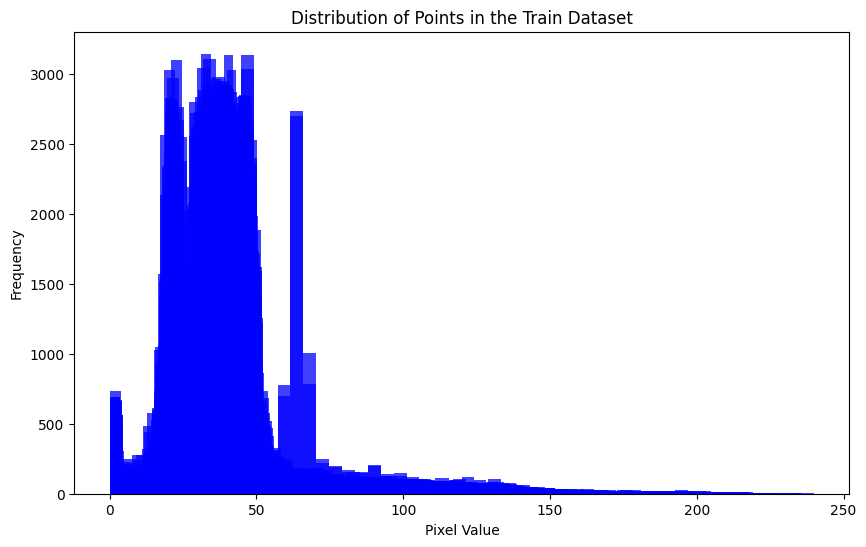

In [280]:
plt.figure(figsize=(10, 6))
plt.title('Distribution of Points in the Train Dataset')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(False)
for i in range(17900, 18400):
    plt.hist(train_images_flattened['Image'][i], bins=50, alpha=0.75, color='blue')
plt.show()

This sample shows also a normal distribution with skewness on the right, however, it also shows noise in the first bin on the left and bins between 60 and 70, give or take.

All these samples show eventually a skewed normal distribution with noise and that is an indicator that there are an extensive number of zeroes in the dataset, so reducing the number of bins will minimize this noise drastically.

In the next part, after experimenting with the number of bins, I decided to choose 255 bins, and that will be clarified next.

**2. Transformation**

Why am I transforming the dataset? Well, the first main reason is dimensionality reduction, and the second one is reducing noise as much as possible without applying any advanced filtering techniques.

The features I am going to create are:

- **Mean**: calculating the mean of the each image pixels.
- **Variance**: calculating the variance of each image pixels.
- **Bins**: creating histogram bins representing the data distribution.

In [37]:
def transform_dataframe(original_dataframe):
    # Copying the flattened original dataframe to a temporary dataframe:
    trans_df = original_dataframe
    
    # Initiating an empty dataframe that will hold the transformed one:
    transformed_dataframe = pd.DataFrame()

    # Getting all the pixels from all the images:
    for img in trans_df['Image']:
        # Initiate an empty list that will hold the data of each row:
        main_list = []
    
        # Append the mean:
        main_list.append(round(np.mean(img), 3))
    
        # Append the variance:
        main_list.append(round(np.var(img), 3))
    
        # Define the Bins for the histogram, using np.linspace to create evenly spaced numbers from 0 to 255:
        bin_edges = np.linspace(0, 255, 256)
    
        # Calculate the Histogram counts by using numpy.histogram.
        hist_counts = np.histogram(img, bins=bin_edges)
    
        # Append the histogram counts to the main list:
        for item in list(hist_counts[0]):
            main_list.append(item)
    
        # Creating a temporary dataframe that will hold each row one at a time:
        temp_df = pd.DataFrame([main_list])
    
        # Append the temp_df to the transformed dataframe:
        transformed_dataframe = pd.concat([transformed_dataframe, temp_df], ignore_index=True)
    
    # Add the 'Label' column:
    transformed_dataframe['Label'] = trans_df['Label'].values

    # Renaming the dataframe columns:
    for i, col in enumerate(transformed_dataframe):
        if col == 0:
            transformed_dataframe.rename(columns={0: 'mean'}, inplace=True)
        elif col == 1:
            transformed_dataframe.rename(columns={1: 'variance'}, inplace=True)
        elif col in range(2, 258):
            transformed_dataframe.rename(columns={col: f"bin_{i-1}"}, inplace=True)
    
    return transformed_dataframe

In [38]:
# Transforming the training dataset:
train_images_flattened_transformed = transform_dataframe(train_images_flattened)
train_images_flattened_transformed

,mean,variance,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,bin_7,bin_8,...,bin_247,bin_248,bin_249,bin_250,bin_251,bin_252,bin_253,bin_254,bin_255,Label
0,91.073,1443.002,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
1,87.113,1004.129,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
2,83.780,697.435,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
3,88.441,1121.173,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
4,88.562,1108.824,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18395,44.594,742.861,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,MH
18396,51.353,793.661,127,93,18,17,18,13,9,4,...,0,0,0,0,0,0,0,0,0,MH
18397,45.611,732.433,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,MH
18398,51.638,1257.245,59,72,45,47,24,15,22,22,...,0,0,0,0,0,0,0,0,0,MH


In [39]:
# Transforming the test dataset:
test_images_flattened_transformed = transform_dataframe(test_images_flattened)
test_images_flattened_transformed

,mean,variance,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,bin_7,bin_8,...,bin_247,bin_248,bin_249,bin_250,bin_251,bin_252,bin_253,bin_254,bin_255,Label
0,90.988,1419.831,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
1,90.784,1379.473,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
2,92.294,1476.151,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
3,88.747,1349.923,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
4,87.239,972.143,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,44.972,677.261,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,MH
2796,55.332,958.108,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,MH
2797,31.340,333.991,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,MH
2798,58.123,603.146,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,MH


In [40]:
# Transforming the validation dataset:
validation_images_flattened_transformed = transform_dataframe(validation_images_flattened)
validation_images_flattened_transformed

,mean,variance,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,bin_7,bin_8,...,bin_247,bin_248,bin_249,bin_250,bin_251,bin_252,bin_253,bin_254,bin_255,Label
0,86.085,609.571,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
1,82.880,599.418,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
2,84.600,731.412,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
3,88.321,1023.891,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
4,86.151,836.813,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,AMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,43.688,402.776,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,MH
2796,51.400,632.635,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,MH
2797,38.424,990.729,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,MH
2798,59.462,841.783,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,MH


The decision to choose 255 bins came from the fact that this number is a good standard when working with grayscaled images, covering all the 255 pixels of the image.

Let's understand the data a bit more in those transformed dataframes and see how much 0 values we have in each column. It is important to deal with 0 values as it can impact our model accuracy.

In [340]:
def counting_zeros_in_columns(dataframe):
    zero_count_dict = {}
    for i, col in enumerate(dataframe):
        counter = 0
        for val in dataframe[col]:
            if val == 0:
                counter += 1
            zero_count_dict[col] = [counter]

    keys = list(zero_count_dict.keys())
    values = list(zero_count_dict.values())
    
    # Convert any array values to scalars if needed. This ensures we're plotting single values for each key:
    scalar_values = []
    for val in values:
        if hasattr(val, '__len__') and len(val) > 0:  # Check if it's an array object
            scalar_values.append(val[0])  # Take the first element if it's an array
        else:
            scalar_values.append(val)  # Use as is if it's already a scalar
    
    # Plot using the keys and scalar values:
    fig, ax = plt.subplots()
    plt.bar(keys, scalar_values)
    ax.set_xticks([])
    plt.show()

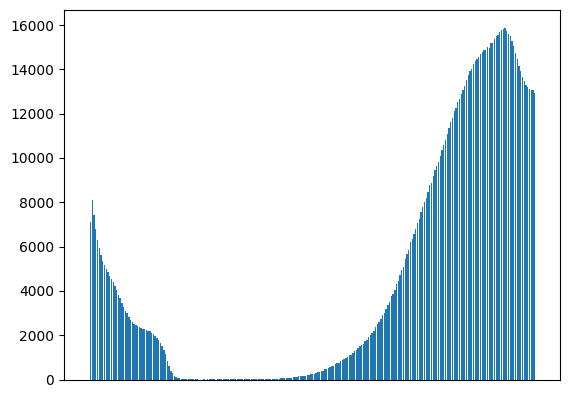

In [341]:
# Counting the 0's in each bin in the training set and visualizing them:
counting_zeros_in_columns(train_images_flattened_transformed)

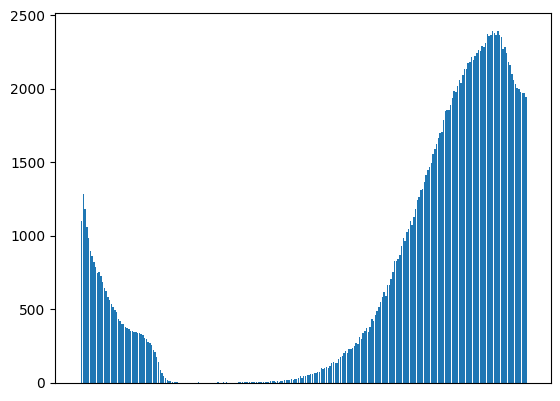

In [342]:
# Counting the 0's in each bin in the test set and visualizing them:
counting_zeros_in_columns(test_images_flattened_transformed)

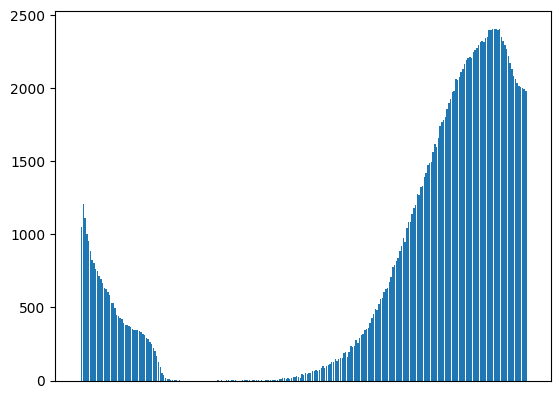

In [343]:
# Counting the 0's in each bin in the validation set and visualizing them:
counting_zeros_in_columns(validation_images_flattened_transformed)

The majority of the 0 pixels in these images could very well represent the black background, as these are OCT images. We can clearly see that the 0's are clustered in the beginning and at the end of the bins, while the middle has little 0's and that is expected since the image has the retina shape in the middle of the picture and the black pixels are on top and bottom.

For sure, there is noise amongst the data, but I am not going to filter them out, as this will need special filtering techniques, such as Speckle Reducing Anisotropic Diffusion, which will not be part of this project, rather I will create a deep learning model which can learn complex noise patterns and apply highly adaptive filtering.

Here are 3 image examples taken one from the training set, one from the test set and one from the validation set:

Train

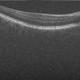

Test

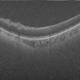

Validation

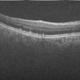

You can see the white area lying more or less in the middle of the image, where this is represented by the small bar sizes in the plots above. On the other hand, the black part of the image represented by zeroes are the large bar sizes.

Pickling the transformed datasets:

In [41]:
# Pickling the training dataset:
train_images_flattened_transformed.to_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\train_images_flat_norm\\train_images_flattened_transformed.pkl')

In [42]:
# Pickling the test dataset:
test_images_flattened_transformed.to_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\test_images_flat_norm\\test_images_flattened_transformed.pkl')

In [43]:
# Pickling the validation dataset:
validation_images_flattened_transformed.to_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\validation_images_flat_norm\\validation_images_flattened_transformed.pkl')

With the filtering done above, not much of the data is lost, whether from the training, test or validation dataset.

Normalizing the dataframes:

In [ ]:
# Normalize the test images:
image_process = Image_Processing('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\test_images_flat_norm\\test_images_flattened_transformed.pkl')
normalized_test_images = image_process.image_normalize_transformed_df(test_images_flattened_transformed)
normalized_test_images.to_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\test_images_flat_norm\\normalized_test_images_flattened_transformed.pkl')

In [ ]:
# Normalize the training images:
image_process = Image_Processing('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\train_images_flat_norm\\train_images_flattened_transformed.pkl')
normalized_train_images = image_process.image_normalize_transformed_df(train_images_flattened_transformed)
normalized_train_images.to_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\train_images_flat_norm\\normalized_train_images.pkl')

In [ ]:
# Normalize the validation images:
image_process = Image_Processing('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\validation_images_flat_norm\\validation_images_flattened_transformed.pkl')
normalized_validation_images = image_process.image_normalize_transformed_df(validation_images_flattened_transformed)
normalized_validation_images.to_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\validation_images_flat_norm\\normalized_validation_images.pkl')

Converting the labels to numerical:

In [47]:
# Converting the test images dataframe labels to numerical values:
normalized_test_images_df = pd.read_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\test_images_flat_norm\\normalized_test_images_flattened_transformed.pkl')
image_process = Image_Processing('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\test_images_flat_norm\\normalized_test_images_flattened_transformed.pkl')
normalized_test_images_updated = image_process.label_to_numeric(normalized_test_images_df)
normalized_test_images_updated

,mean,variance,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,bin_7,bin_8,...,bin_247,bin_248,bin_249,bin_250,bin_251,bin_252,bin_253,bin_254,bin_255,Label
0,2.007184,-0.209776,-0.373668,-0.324532,-0.426596,-0.426159,-0.29448,-0.291868,-0.356629,-0.42485,...,-0.441807,-0.463484,-0.480385,-0.497359,-0.50314,-0.506601,-0.501434,-0.499617,-0.340611,1
1,1.996198,-0.233057,-0.373668,-0.324532,-0.426596,-0.426159,-0.29448,-0.291868,-0.356629,-0.42485,...,-0.441807,-0.463484,-0.480385,-0.497359,-0.50314,-0.506601,-0.501434,-0.499617,-0.340611,1
2,2.077519,-0.177287,-0.373668,-0.324532,-0.426596,-0.426159,-0.29448,-0.291868,-0.356629,-0.42485,...,-0.441807,-0.463484,-0.480385,-0.497359,-0.50314,-0.506601,-0.501434,-0.499617,-0.340611,1
3,1.886495,-0.250103,-0.373668,-0.324532,-0.426596,-0.426159,-0.29448,-0.291868,-0.356629,-0.42485,...,-0.441807,-0.463484,-0.480385,-0.497359,-0.50314,-0.506601,-0.501434,-0.499617,-0.340611,1
4,1.805282,-0.468028,-0.373668,-0.324532,-0.426596,-0.426159,-0.29448,-0.291868,-0.356629,-0.42485,...,-0.441807,-0.463484,-0.480385,-0.497359,-0.50314,-0.506601,-0.501434,-0.499617,-0.340611,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,-0.471009,-0.638133,-0.373668,-0.324532,-0.426596,-0.426159,-0.29448,-0.276068,-0.344691,-0.42485,...,-0.441807,-0.463484,-0.480385,-0.497359,-0.50314,-0.506601,-0.501434,-0.499617,-0.340611,8
2796,0.086929,-0.476124,-0.373668,-0.324532,-0.426596,-0.426159,-0.29448,-0.291868,-0.356629,-0.42485,...,-0.441807,-0.463484,-0.480385,-0.497359,-0.50314,-0.506601,-0.501434,-0.499617,-0.340611,8
2797,-1.205161,-0.836151,-0.373668,-0.324532,-0.426596,-0.426159,-0.29448,-0.291868,-0.356629,-0.42485,...,-0.441807,-0.463484,-0.480385,-0.497359,-0.50314,-0.506601,-0.501434,-0.499617,-0.340611,8
2798,0.237238,-0.680887,-0.373668,-0.324532,-0.426596,-0.426159,-0.29448,-0.291868,-0.356629,-0.42485,...,-0.441807,-0.463484,-0.480385,-0.497359,-0.50314,-0.506601,-0.501434,-0.499617,-0.340611,8


In [48]:
# Converting the validation images dataframe labels to numerical values:
normalized_validation_images_df = pd.read_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\validation_images_flat_norm\\normalized_validation_images.pkl')
image_process = Image_Processing('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\validation_images_flat_norm\\normalized_validation_images.pkl')
normalized_validation_images_updated = image_process.label_to_numeric(normalized_validation_images_df)
normalized_validation_images_updated

,mean,variance,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,bin_7,bin_8,...,bin_247,bin_248,bin_249,bin_250,bin_251,bin_252,bin_253,bin_254,bin_255,Label
0,1.859248,-0.678824,-0.374699,-0.328714,-0.438918,-0.517319,-0.270568,-0.327852,-0.375973,-0.428386,...,-0.433341,-0.452203,-0.470033,-0.485246,-0.493606,-0.48752,-0.488235,-0.493485,-0.339473,1
1,1.679183,-0.684999,-0.374699,-0.328714,-0.438918,-0.517319,-0.270568,-0.327852,-0.375973,-0.428386,...,-0.433341,-0.452203,-0.470033,-0.485246,-0.493606,-0.48752,-0.488235,-0.493485,-0.339473,1
2,1.775817,-0.604720,-0.374699,-0.328714,-0.438918,-0.517319,-0.270568,-0.327852,-0.375973,-0.428386,...,-0.433341,-0.452203,-0.470033,-0.485246,-0.493606,-0.48752,-0.488235,-0.493485,-0.339473,1
3,1.984873,-0.426833,-0.374699,-0.328714,-0.438918,-0.517319,-0.270568,-0.327852,-0.375973,-0.428386,...,-0.433341,-0.452203,-0.470033,-0.485246,-0.493606,-0.48752,-0.488235,-0.493485,-0.339473,1
4,1.862956,-0.540614,-0.374699,-0.328714,-0.438918,-0.517319,-0.270568,-0.327852,-0.375973,-0.428386,...,-0.433341,-0.452203,-0.470033,-0.485246,-0.493606,-0.48752,-0.488235,-0.493485,-0.339473,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,-0.522728,-0.804598,-0.374699,-0.328714,-0.438918,-0.517319,-0.270568,-0.327852,-0.375973,-0.428386,...,-0.433341,-0.452203,-0.470033,-0.485246,-0.493606,-0.48752,-0.488235,-0.493485,-0.339473,8
2796,-0.089448,-0.664796,-0.374699,-0.328714,-0.438918,-0.517319,-0.270568,-0.327852,-0.375973,-0.428386,...,-0.433341,-0.452203,-0.470033,-0.485246,-0.493606,-0.48752,-0.488235,-0.493485,-0.339473,8
2797,-0.818474,-0.447002,-0.374699,-0.328714,-0.438918,-0.517319,-0.270568,-0.327852,-0.375973,-0.410113,...,-0.433341,-0.452203,-0.470033,-0.485246,-0.493606,-0.48752,-0.488235,-0.493485,-0.339473,8
2798,0.363497,-0.537592,-0.374699,-0.328714,-0.438918,-0.517319,-0.270568,-0.327852,-0.375973,-0.428386,...,-0.433341,-0.452203,-0.470033,-0.485246,-0.493606,-0.48752,-0.488235,-0.493485,-0.339473,8


In [49]:
# Converting the training images dataframe labels to numerical values:
normalized_train_images_df = pd.read_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\train_images_flat_norm\\normalized_train_images.pkl')
image_process = Image_Processing('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\train_images_flat_norm\\normalized_train_images.pkl')
normalized_train_images_updated = image_process.label_to_numeric(normalized_train_images_df)
normalized_train_images_updated

,mean,variance,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,bin_7,bin_8,...,bin_247,bin_248,bin_249,bin_250,bin_251,bin_252,bin_253,bin_254,bin_255,Label
0,2.064984,-0.182917,-0.374481,-0.318303,-0.429767,-0.483019,-0.318069,-0.314756,-0.366608,-0.437071,...,-0.439917,-0.464983,-0.475971,-0.491328,-0.496997,-0.496024,-0.49999,-0.502236,-0.339264,1
1,1.847774,-0.441405,-0.374481,-0.318303,-0.429767,-0.483019,-0.318069,-0.314756,-0.366608,-0.437071,...,-0.439917,-0.464983,-0.475971,-0.491328,-0.496997,-0.496024,-0.49999,-0.502236,-0.339264,1
2,1.664956,-0.622041,-0.374481,-0.318303,-0.429767,-0.483019,-0.318069,-0.314756,-0.366608,-0.437071,...,-0.439917,-0.464983,-0.475971,-0.491328,-0.496997,-0.496024,-0.49999,-0.502236,-0.339264,1
3,1.920616,-0.372468,-0.374481,-0.318303,-0.429767,-0.483019,-0.318069,-0.314756,-0.366608,-0.437071,...,-0.439917,-0.464983,-0.475971,-0.491328,-0.496997,-0.496024,-0.49999,-0.502236,-0.339264,1
4,1.927253,-0.379741,-0.374481,-0.318303,-0.429767,-0.483019,-0.318069,-0.314756,-0.366608,-0.437071,...,-0.439917,-0.464983,-0.475971,-0.491328,-0.496997,-0.496024,-0.49999,-0.502236,-0.339264,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18395,-0.484432,-0.595286,-0.374481,-0.318303,-0.429767,-0.483019,-0.318069,-0.314756,-0.366608,-0.437071,...,-0.439917,-0.464983,-0.475971,-0.491328,-0.496997,-0.496024,-0.49999,-0.502236,-0.339264,8
18396,-0.113695,-0.565366,1.667204,2.021217,0.474977,0.607352,0.213284,-0.103315,-0.265540,-0.399052,...,-0.439917,-0.464983,-0.475971,-0.491328,-0.496997,-0.496024,-0.49999,-0.502236,-0.339264,8
18397,-0.428649,-0.601428,-0.374481,-0.318303,-0.429767,-0.483019,-0.318069,-0.314756,-0.366608,-0.437071,...,-0.439917,-0.464983,-0.475971,-0.491328,-0.496997,-0.496024,-0.49999,-0.502236,-0.339264,8
18398,-0.098062,-0.292324,0.574019,1.492938,1.832092,2.531535,0.390402,-0.070785,-0.119552,-0.227965,...,-0.439917,-0.464983,-0.475971,-0.491328,-0.496997,-0.496024,-0.49999,-0.502236,-0.339264,8


#### **Creating the Prediction Models**

I will use Gaussian Naive Bayes approach without using any Python libraries or packages; the model will be built using pure mathematics.

If we look under the hood of a Gaussian Naive Bayes model, it basically works as follows:

-  **Fitting**: here we calculate the priors, means and variances for each image and for each class, and we store those values in a particular data structure; dictionaries are convenient in this case.
-  **Predicting**: in prediction we calculate for each image the likelihood of each class using the PDF of the distribution and plugging in the values of the priors, means and variances that were calculated in the fitting step.

**Gaussian Naive Bayes with Normal Distribution**

We need to apply the Gaussian Naive Bayes formula for a Normal Distribution represented by $P(x_i|y) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$

In [50]:
class Gaussian_Naive_Bayes:
    def __init__(self):
        # Dictionary to store prior probabilities for each class:
        self.priors = {}
        # Dictionary to store means for each feature per class:
        self.means = {}
        # Dictionary to store variances for each feature per class:
        self.variances = {}
        # List to store unique class labels:
        self.classes = []
        # Small value to add to variance to prevent division by zero:
        self.epsilon = 1e-6

    def fit(self, X, y):  # X represents the features (pixel data) and y represents the labels.
        self.classes = np.unique(y)
        n_samples, n_features = X.shape

        for c in self.classes:
            # Filter data for the current class:
            X_c = X[y == c]

            # Calculate prior probability:
            self.priors[c] = len(X_c) / n_samples

            # Calculate mean for each feature for the current class:
            self.means[c] = X_c.mean(axis=0)

            # Calculate variance for each feature for the current class and add epsilon to avoid zero variance:
            self.variances[c] = X_c.var(axis=0) + self.epsilon

        print("Model training complete.")

    # Calculate the likelihood of a feature given the class:
    def calculate_likelihood(self, feature_value, mean, variance):
        # Gaussian PDF formula: (1 / sqrt(2 * pi * variance)) * exp(- (x - mean)^2 / (2 * variance))
        numerator = np.exp(-((feature_value - mean) ** 2) / (2 * variance))
        denominator = np.sqrt(2 * np.pi * variance)
        return numerator / denominator

    # Calculate the likelihood by predicting the class for a single sample:
    def predict_single_sample(self, x):
        # Initialize a list to store the log posterior probabilities for each class:
        posteriors = []

        for c in self.classes:
            # Start with the log of the prior probability, using log probabilities to convert the multinomial Bayesian classification to linear classification:
            log_posterior = np.log(self.priors[c])

            # Add the log likelihoods for each feature:
            # P(X | C_k) = Product(P(x_i | C_k))
            # log(P(X | C_k)) = Sum(log(P(x_i | C_k)))
            # Here, P(x_i | C_k) is calculated using the Gaussian PDF
            for i in range(len(x)):
                likelihood = self.calculate_likelihood(x[i], self.means[c][i], self.variances[c][i])
                # Add a small value to likelihood to prevent log(0) if likelihood is exactly zero:
                log_posterior += np.log(likelihood + self.epsilon)

            posteriors.append(log_posterior)

        # The class with the highest log posterior probability is the prediction result:
        return self.classes[np.argmax(posteriors)]

    # Predicts the class labels for multiple samples with Shape(n_samples, n_features):
    def predict(self, X):
        # Predict the class for each sample in X:
        predictions = [self.predict_single_sample(x) for x in X]
        return np.array(predictions)
    
    # Calculate the accuracy of the model:
    def accuracy(self, X, y_true, y_pred):
        correct_predictions = np.sum(y_pred == y_true)
        total_predictions = len(y_true)
        accuracy = correct_predictions / total_predictions
        return accuracy

***Training and prediction on the flattened data - method 1:***

In [318]:
# Select feature columns (all except 'Label') and label column for training set
X = np.stack(normalized_train_images_final['Image'].values)
y = normalized_train_images_final['Label'].values

# Select feature columns and label column for test set
X_test = np.stack(normalized_test_images_final['Image'].values)
y_test = normalized_test_images_final['Label'].values

# Select feature columns and label column for validation set
X_val = np.stack(normalized_validation_images_final['Image'].values)
y_val = normalized_validation_images_final['Label'].values

# Initialize and train the model:
model = Gaussian_Naive_Bayes()
model.fit(X, y)

print("\n###### Predictions and Accuracy - Flattened Data ######")

# Predict the labels for the test set:
predictions = model.predict(X_test)

# Calculate the accuracy for the current batch using the validation set:
accuracy = model.accuracy(X_val, y_val, predictions)

print(f"Accuracy on the full training dataset: {round(accuracy*100, 2)}")

Model training complete.

###### Predictions and Accuracy - Flattened Data ######
Accuracy on the full training dataset: 34.32


**Gaussian Naive Bayes with Gamma Distribution**

Here we need to apply this formula representing the Gamma Distribution $f(x; a, b) = \frac{1}{b^a\Gamma(a)} x^{a-1}e^{-x/b}$

In [12]:
from scipy.special import loggamma

class Gamma_Naive_Bayes:
    def __init__(self):
        # Dictionary to store prior probabilities for each class:
        self.priors = {}
        # Dictionaries to store shape (alpha) and rate (beta) parameters for each feature per class:
        self.shapes = {}
        self.rates = {}
        # List to store unique class labels:
        self.classes = []
        # Small value to add to variance during parameter estimation to prevent division by zero:
        self.epsilon_var = 1e-6
        # Small value to add to pixel values to ensure they are strictly positive for Gamma PDF:
        self.epsilon_shift = 1e-9
        # Value to store the minimum observed pixel value for shifting:
        self.min_pixel_value = 0.0

    def fit(self, X, y): # X represents the features (pixel data) and y represents the labels.
        self.classes = np.unique(y)
        n_samples, n_features = X.shape

        # Determine the minimum pixel value across the entire dataset for shifting.
        # This ensures all pixel values become positive for Gamma distribution:
        self.min_pixel_value = np.min(X)
        X_shifted = X - self.min_pixel_value + self.epsilon_shift

        for c in self.classes:
            # Filter data for the current class and apply the same shift:
            X_c = X_shifted[y == c]

            # Calculate prior probability:
            self.priors[c] = len(X_c) / n_samples

            # Calculate mean and variance for each feature for the current class.
            # These are used to estimate Gamma parameters:
            feature_means = X_c.mean(axis=0)
            # Add epsilon to variance for numerical stability:
            feature_variances = X_c.var(axis=0) + self.epsilon_var

            # Estimate Gamma parameters (shape alpha, rate beta) using method of moments.
            # alpha = mean^2 / variance
            # beta = mean / variance (rate parameter, 1/scale)
            # Add a small epsilon to feature_means to prevent division by zero for rate and shape if the mean is zero or very close to zero.
            safe_feature_means = feature_means + self.epsilon_shift

            self.shapes[c] = (safe_feature_means**2) / feature_variances
            self.rates[c] = safe_feature_means / feature_variances

            # Further ensure shapes and rates are not NaN or Inf, and are strictly positive.
            # np.nan_to_num replaces NaNs with 0, and Infs with large finite numbers.
            # We then clamp any non-positive values to epsilon_var.
            self.shapes[c] = np.nan_to_num(self.shapes[c], nan=self.epsilon_var, posinf=1.0/self.epsilon_var, neginf=self.epsilon_var)
            self.rates[c] = np.nan_to_num(self.rates[c], nan=self.epsilon_var, posinf=1.0/self.epsilon_var, neginf=self.epsilon_var)

            # Ensure values are strictly positive, as required for Gamma distribution parameters:
            self.shapes[c][self.shapes[c] <= 0] = self.epsilon_var
            self.rates[c][self.rates[c] <= 0] = self.epsilon_var

        print("Gamma Naive Bayes model training complete.")

    # Calculate the likelihood of a feature given the class:
    def calculate_likelihood(self, feature_value, shape, rate):
        # Gamma log-PDF formula: alpha * log(beta) + (alpha - 1) * log(x) - beta * x - log(Gamma(alpha))
        x = feature_value # Already shifted to be positive

        # Handle cases where shape or rate might be problematic, such as very small or zero.
        # Return a very small negative value (log of a very small positive value).
        # The fit method ensures shape and rate are positive:
        if shape <= 0 or rate <= 0 or x <= 0:
            return np.log(self.epsilon_var) # log(1e-6) is approx -13.8, a very small log-likelihood

        # Calculate log-likelihood terms:
        term1 = shape * np.log(rate)
        term2 = (shape - 1) * np.log(x)
        term3 = -rate * x
        term4 = loggamma(shape) # Use scipy.special.loggamma for log(Gamma(alpha))

        log_likelihood = term1 + term2 + term3 - term4
        return log_likelihood

    # Calculate the likelihood by predicting the class for a single sample:
    def predict_single_sample(self, x):
        posteriors = []

        # Apply the same shift to the input sample as was applied during training:
        x_shifted = x - self.min_pixel_value + self.epsilon_shift

        for c in self.classes:
            # Start with the log of the prior probability:
            log_posterior = np.log(self.priors[c])

            # Add the log likelihoods for each feature:
            for i in range(len(x_shifted)):
                log_likelihood = self.calculate_likelihood(
                    x_shifted[i], self.shapes[c][i], self.rates[c][i]
                )
                log_posterior += log_likelihood

            posteriors.append(log_posterior)

        # The class with the highest log posterior probability is the prediction:
        return self.classes[np.argmax(posteriors)]

    # Predicts the class labels for multiple samples with Shape(n_samples, n_features):
    def predict(self, X):
        predictions = [self.predict_single_sample(x) for x in X]
        return np.array(predictions)
    
    # Calculate the accuracy of the model:
    def accuracy(self, X, y_true, y_pred):
        correct_predictions = np.sum(y_pred == y_true)
        total_predictions = len(y_true)
        accuracy = correct_predictions / total_predictions
        return accuracy

In [357]:
# Select feature columns (all except 'Label') and label column for training set
X = np.stack(normalized_train_images_final['Image'].values)
y = normalized_train_images_final['Label'].values

# Select feature columns and label column for test set
X_test = np.stack(normalized_test_images_final['Image'].values)
y_test = normalized_test_images_final['Label'].values

# Select feature columns and label column for validation set
X_val = np.stack(normalized_validation_images_final['Image'].values)
y_val = normalized_validation_images_final['Label'].values

# Initialize and train the model:
model = Gamma_Naive_Bayes()
model.fit(X, y)

print("\n###### Predictions and Accuracy - Flattened Data ######")

# Predict the labels for the test set:
predictions = model.predict(X_test)

# Calculate the accuracy for the current batch using the validation set:
accuracy = model.accuracy(X_val, y_val, predictions)

print(f"Accuracy on the full training dataset: {round(accuracy*100, 2)}")

Gamma Naive Bayes model training complete.

###### Predictions and Accuracy - Flattened Data ######
Accuracy on the full training dataset: 34.93


***Training and prediction on the transformed data - method 2:***

Normal Distribution:

In [51]:
# Select feature columns (all except 'Label') and label column for training set
X = normalized_train_images_updated.drop('Label', axis=1).values
y = normalized_train_images_updated['Label'].values

# Select feature columns and label column for test set
X_test = normalized_test_images_updated.drop('Label', axis=1).values
y_test = normalized_test_images_updated['Label'].values

# Select feature columns and label column for validation set
X_val = normalized_validation_images_updated.drop('Label', axis=1).values
y_val = normalized_validation_images_updated['Label'].values

# Initialize and train the model:
model = Gaussian_Naive_Bayes()
model.fit(X, y)

print("\n###### Predictions and Accuracy - Transformed Data ######")

# Predict the labels for the test set:
predictions = model.predict(X_test)

# Calculate the accuracy for the current batch using the validation set:
accuracy = model.accuracy(X_val, y_val, predictions)

print(f"Accuracy on the full training dataset: {round(accuracy*100, 2)}")

Model training complete.

###### Predictions and Accuracy - Transformed Data ######
Accuracy on the full training dataset: 51.11


Gamma Distribution:

In [52]:
# Select feature columns (all except 'Label') and label column for training set
X = normalized_train_images_updated.drop('Label', axis=1).values
y = normalized_train_images_updated['Label'].values

# Select feature columns and label column for test set
X_test = normalized_test_images_updated.drop('Label', axis=1).values
y_test = normalized_test_images_updated['Label'].values

# Select feature columns and label column for validation set
X_val = normalized_validation_images_updated.drop('Label', axis=1).values
y_val = normalized_validation_images_updated['Label'].values

# Initialize and train the model:
model = Gamma_Naive_Bayes()
model.fit(X, y)

print("\n###### Predictions and Accuracy - Transformed Data ######")

# Predict the labels for the test set:
predictions = model.predict(X_test)

# Calculate the accuracy for the current batch using the validation set:
accuracy = model.accuracy(X_val, y_val, predictions)

print(f"Accuracy on the full training dataset: {round(accuracy*100, 2)}")

Gamma Naive Bayes model training complete.

###### Predictions and Accuracy - Transformed Data ######
Accuracy on the full training dataset: 39.68


**Assessment of the Naive Bayes model**

In [72]:
# Creating a dictionary that holds the prediction results from the Normal Distribution and the Gamma Distribution for flattened and trasformed datasets:
pred_res = {'Flattened_Datasets': {'Normal_Dist': '34.32%', 'Gamma_Dist': '34.93%'},
            'Transformed_Datasets': {'Normal_Dist': '51.11%', 'Gamma_Dist': '39.68%'}
           }
pred_res_df = pd.DataFrame(pred_res)
pred_res_df

,Flattened_Datasets,Transformed_Datasets
Normal_Dist,34.32%,51.11%
Gamma_Dist,34.93%,39.68%


Using the Flattened Datasets method the model did not perform well, however, with the Transformed Datasets the model performed around 15% better giving an accuracy score of 51% for the Normal Distribution.

The Gaussian Naive Bayes with Normal Distribution performed better than the Gamma Distribution, but in general, both distributions did not perform good due to the fact that noisy data is not completely filtered.

Using a deep learning approach next, I hope to have better accuracy.

#### **Method 3: Preparing the dataframes for deep learning**

For deep learning using Convolutional Neural Network, it is recommended not to flatten the images to 1D, rather using a 4D input tensor with a shape of (batch_size, height, width, channels).

For that, I am going to keep the 2D image arrays as they originally are.

**Reading the dataframes**

In [11]:
# Reading the train dataframe:
train_images_2D = pd.read_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\train_images_short.pkl')
train_images_2D

,Image,Label
0,"[[73, 74, 76, 79, 82, 85, 87, 89, 88, 90, 93, ...",AMD
1,"[[94, 94, 96, 96, 96, 94, 93, 92, 86, 86, 87, ...",AMD
2,"[[102, 100, 97, 90, 79, 72, 77, 86, 100, 102, ...",AMD
3,"[[103, 104, 103, 99, 96, 97, 101, 105, 102, 10...",AMD
4,"[[83, 89, 90, 84, 79, 77, 72, 66, 67, 67, 67, ...",AMD
...,...,...
18395,"[[31, 31, 31, 28, 26, 24, 25, 27, 30, 30, 30, ...",MH
18396,"[[97, 105, 106, 92, 73, 56, 40, 27, 47, 27, 40...",MH
18397,"[[28, 28, 28, 28, 28, 28, 28, 28, 26, 28, 31, ...",MH
18398,"[[4, 4, 3, 3, 2, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,...",MH


In [12]:
# Reading the test dataframe:
test_images_2D = pd.read_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\test_images_short.pkl')
test_images_2D

,Image,Label
0,"[[77, 79, 82, 87, 92, 98, 102, 105, 101, 100, ...",AMD
1,"[[171, 171, 170, 168, 167, 165, 164, 163, 161,...",AMD
2,"[[120, 123, 123, 121, 122, 127, 129, 127, 129,...",AMD
3,"[[115, 117, 121, 125, 129, 133, 135, 136, 134,...",AMD
4,"[[82, 76, 71, 72, 80, 90, 97, 99, 107, 109, 11...",AMD
...,...,...
2795,"[[30, 30, 30, 30, 30, 30, 30, 30, 31, 31, 31, ...",MH
2796,"[[36, 36, 37, 38, 40, 41, 42, 42, 40, 39, 39, ...",MH
2797,"[[19, 19, 19, 19, 19, 19, 19, 19, 20, 19, 19, ...",MH
2798,"[[41, 41, 42, 42, 43, 43, 44, 44, 43, 44, 45, ...",MH


In [13]:
# Reading the validation dataframe:
validation_images_2D = pd.read_pickle('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\validation_images_short.pkl')
validation_images_2D

,Image,Label
0,"[[127, 124, 121, 119, 118, 119, 120, 122, 118,...",AMD
1,"[[169, 172, 174, 173, 170, 168, 168, 170, 171,...",AMD
2,"[[149, 149, 148, 147, 144, 140, 136, 134, 127,...",AMD
3,"[[90, 89, 89, 88, 87, 86, 85, 85, 78, 76, 74, ...",AMD
4,"[[87, 90, 93, 96, 98, 98, 97, 95, 98, 98, 98, ...",AMD
...,...,...
2795,"[[41, 26, 20, 30, 38, 33, 29, 30, 21, 26, 31, ...",MH
2796,"[[18, 19, 19, 20, 20, 21, 21, 21, 20, 20, 20, ...",MH
2797,"[[19, 19, 19, 18, 18, 17, 17, 17, 17, 18, 18, ...",MH
2798,"[[41, 44, 47, 47, 45, 43, 42, 42, 43, 43, 43, ...",MH


**Normalizing the original datasets**

In [14]:
# Normalize the original train images:
image_process = Image_Processing('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\train_images_short.pkl')
normalized_train_images_2D = image_process.image_normalize_original_df(train_images_2D)
normalized_train_images_2D

,Image,Label
0,"[[-0.4757771620398047, -0.44945227086710715, -...",AMD
1,"[[0.2173437655485226, 0.2173437655485226, 0.28...",AMD
2,"[[0.6899043812332816, 0.6141726343267244, 0.50...",AMD
3,"[[0.4347936654365096, 0.4646587521957654, 0.43...",AMD
4,"[[-0.1670329154813622, 0.013152604491790142, 0...",AMD
...,...,...
18395,"[[-0.4987700273691234, -0.4987700273691234, -0...",MH
18396,"[[1.620292662420826, 1.9042626231107225, 1.939...",MH
18397,"[[-0.6507148274938899, -0.6507148274938899, -0...",MH
18398,"[[-1.3435171604916718, -1.3435171604916718, -1...",MH


In [15]:
# Normalize the original test images:
image_process = Image_Processing('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\test_images_short.pkl')
normalized_test_images_2D = image_process.image_normalize_original_df(test_images_2D)
normalized_test_images_2D

,Image,Label
0,"[[-0.37123666446183173, -0.31815901880457637, ...",AMD
1,"[[2.159761351065201, 2.159761351065201, 2.1328...",AMD
2,"[[0.7211321794028388, 0.7992150790285713, 0.79...",AMD
3,"[[0.7145484547633246, 0.7689831134447506, 0.87...",AMD
4,"[[-0.1680406698713275, -0.3604766033992704, -0...",AMD
...,...,...
2795,"[[-0.5753230452358062, -0.5753230452358062, -0...",MH
2796,"[[-0.624539271216585, -0.624539271216585, -0.5...",MH
2797,"[[-0.6752405763553014, -0.6752405763553014, -0...",MH
2798,"[[-0.697223101802175, -0.697223101802175, -0.6...",MH


In [16]:
# Normalize the original validation images:
image_process = Image_Processing('C:\\Users\\cesar\\OneDrive\\Documents\\Cesar documents\\Data Science Projects\\Image Classification\\Healthcare\\Pickle datasets\\updated pickled datsets\\validation_images_short.pkl')
normalized_validation_images_2D = image_process.image_normalize_original_df(validation_images_2D)
normalized_validation_images_2D

,Image,Label
0,"[[1.657163806961228, 1.5356546201516226, 1.414...",AMD
1,"[[3.517547355743547, 3.640081295842276, 3.7217...",AMD
2,"[[2.3812321119223885, 2.3812321119223885, 2.34...",AMD
3,"[[0.052468601886860464, 0.021216945109205042, ...",AMD
4,"[[0.02935118047107902, 0.13305796461622363, 0....",AMD
...,...,...
2795,"[[-0.1339189634344836, -0.8813301889277926, -1...",MH
2796,"[[-1.3279257543775738, -1.2881678702446762, -1...",MH
2797,"[[-0.6171101858678707, -0.6171101858678707, -0...",MH
2798,"[[-0.6363149970619771, -0.5329148198067619, -0...",MH


**One-Hot Encoding**

Using One-Hot Encoding creates a column for each label and fills "1" under the respective label of the image.

It is an easy to understand approach; I will show you how in the next cells. This is very important for the Convolutional Neural Network to learn from the data efficiently.

In [17]:
# One-Hot Encoding function:
def one_hot_encode(dataframe):
    # Define the column that holds the labels or categories:
    label_column = ['Label']

    # Initialize the encoder object:
    encoder = OneHotEncoder(sparse_output=False)

    # Encode the labels/categories using the encoder:
    one_hot_encoded_label = encoder.fit_transform(dataframe[label_column])

    # Create a dataframe out of the encoded labels:
    one_hot_encoded_label_df = pd.DataFrame(one_hot_encoded_label, columns=encoder.get_feature_names_out(label_column))

    # Concatenate the encoded label dataframe with the original dataframe:
    final_encoded_df = pd.concat([dataframe, one_hot_encoded_label_df], axis=1)

    # Drop the categorical label column: 
    final_encoded_df = final_encoded_df.drop(label_column, axis=1)
    
    return final_encoded_df

In [18]:
# One_Hot Encoded train dataset:
one_hot_encoded_train_df = one_hot_encode(normalized_train_images_2D)
one_hot_encoded_train_df

,Image,Label_AMD,Label_CNV,Label_CSR,Label_DME,Label_DR,Label_DRUSEN,Label_MH,Label_NORMAL
0,"[[-0.4757771620398047, -0.44945227086710715, -...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"[[0.2173437655485226, 0.2173437655485226, 0.28...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"[[0.6899043812332816, 0.6141726343267244, 0.50...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"[[0.4347936654365096, 0.4646587521957654, 0.43...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"[[-0.1670329154813622, 0.013152604491790142, 0...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
18395,"[[-0.4987700273691234, -0.4987700273691234, -0...",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18396,"[[1.620292662420826, 1.9042626231107225, 1.939...",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18397,"[[-0.6507148274938899, -0.6507148274938899, -0...",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18398,"[[-1.3435171604916718, -1.3435171604916718, -1...",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [19]:
# One_Hot Encoded test dataset:
one_hot_encoded_test_df = one_hot_encode(normalized_test_images_2D)
one_hot_encoded_test_df

,Image,Label_AMD,Label_CNV,Label_CSR,Label_DME,Label_DR,Label_DRUSEN,Label_MH,Label_NORMAL
0,"[[-0.37123666446183173, -0.31815901880457637, ...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"[[2.159761351065201, 2.159761351065201, 2.1328...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"[[0.7211321794028388, 0.7992150790285713, 0.79...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"[[0.7145484547633246, 0.7689831134447506, 0.87...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"[[-0.1680406698713275, -0.3604766033992704, -0...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2795,"[[-0.5753230452358062, -0.5753230452358062, -0...",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2796,"[[-0.624539271216585, -0.624539271216585, -0.5...",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2797,"[[-0.6752405763553014, -0.6752405763553014, -0...",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2798,"[[-0.697223101802175, -0.697223101802175, -0.6...",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [20]:
# One_Hot Encoded validation dataset:
one_hot_encoded_validation_df = one_hot_encode(normalized_validation_images_2D)
one_hot_encoded_validation_df

,Image,Label_AMD,Label_CNV,Label_CSR,Label_DME,Label_DR,Label_DRUSEN,Label_MH,Label_NORMAL
0,"[[1.657163806961228, 1.5356546201516226, 1.414...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"[[3.517547355743547, 3.640081295842276, 3.7217...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"[[2.3812321119223885, 2.3812321119223885, 2.34...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"[[0.052468601886860464, 0.021216945109205042, ...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"[[0.02935118047107902, 0.13305796461622363, 0....",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2795,"[[-0.1339189634344836, -0.8813301889277926, -1...",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2796,"[[-1.3279257543775738, -1.2881678702446762, -1...",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2797,"[[-0.6171101858678707, -0.6171101858678707, -0...",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2798,"[[-0.6363149970619771, -0.5329148198067619, -0...",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


**Creating the features and target for the Convolutional Neural Network**

In [21]:
# Function to process the dataframes for CNN:
def feature_label_creation(dataframe, image_height, image_width, channels):
    # Define the label columns:
    label_columns = ['Label_AMD', 'Label_CNV', 'Label_CSR', 'Label_DME', 'Label_DR', 'Label_DRUSEN', 'Label_MH', 'Label_NORMAL']
    
    # Initialize a list to hold the processed images:
    processed_images = []

    # Initialize a list to hold the processed labels:
    processed_labels = []

    # Initialize a counter to count how many arrays could not be processed, if any:
    unprocessed_counter = 0

    print(f"\n###### Processing DataFrame with {len(dataframe)} samples ######")

    for i, row in dataframe.iterrows():
        # Getting the features, in this case the images and converting them to numpy array: 
        img_array = np.array(row['Image'], dtype=np.float32)

        # Getting each label column and converting it to numpy array:
        label_one_hot = row[label_columns].values.astype(np.float32)

        try:
            # Get the shape to see if we need to add channel dimension:
            current_shape = img_array.shape
            current_ndim = img_array.ndim

            # Ensure the image has a shape of (H, W, 1) for CNN input.
            # If shape is (H, W), add a channel dimension:
            if current_ndim == 2:
                img_array = np.expand_dims(img_array, axis=-1)
            # If the shape is already (H, W, 1):
            elif current_ndim == 3 and current_shape[2] == 1:
                pass
            else:
                raise ValueError(f"Unexpected image array shape for grayscale: {current_shape}. Expected (H, W) or (H, W, 1).")

            # Validate that height and width match 80 x 80 size:
            if img_array.shape[0] != image_height or img_array.shape[1] != image_width:
                 raise ValueError(f"Image not at the required size. Expected ({image_height}, {image_width}), got ({img_array.shape[0]}, {img_array.shape[1]})")

            # Final check of shape before appending:
            if img_array.shape != (image_height, image_width, channels):
                raise ValueError(f"Array shape mismatch. Expected ({image_height}, {image_width}, {channels}), got {img_array.shape}")

            # Append the feature and labels arrays:
            processed_images.append(img_array) # Append the prepared numpy array
            processed_labels.append(label_one_hot)

        except Exception as e:
            print(f"Error processing row {i}: {e}")
            skipped_count += 1

    print(f"###### Finished processing. Skipped {unprocessed_counter} samples ######")

    # Finally, convert the lists to numpy arrays:
    X = np.array(processed_images)
    y = np.array(processed_labels)

    return X, y

In [22]:
# Processing the training images.
# Image shape parameters:
img_height = 80
img_width = 80
channels = 1

# Create the X_train and y_train:
X_train, y_train = feature_label_creation(one_hot_encoded_train_df, img_height, img_width, channels)
print(f"\nShape of X_train: {X_train.shape}, y_train: {y_train.shape}")


###### Processing DataFrame with 18400 samples ######
###### Finished processing. Skipped 0 samples ######

Shape of X_train: (18400, 80, 80, 1), y_train: (18400, 8)


In [23]:
# Processing the test images:
# Image shape parameters:
img_height = 80
img_width = 80
channels = 1

# Create the X_test and y_test:
X_test, y_test = feature_label_creation(one_hot_encoded_test_df, img_height, img_width, channels)
print(f"\nShape of X_test: {X_test.shape}, y_test: {y_test.shape}")


###### Processing DataFrame with 2800 samples ######
###### Finished processing. Skipped 0 samples ######

Shape of X_test: (2800, 80, 80, 1), y_test: (2800, 8)


In [24]:
# Processing the validation images:
# Image shape parameters:
img_height = 80
img_width = 80
channels = 1

# Create the X_validation and y_validation:
X_validation, y_validation = feature_label_creation(one_hot_encoded_validation_df, img_height, img_width, channels)
print(f"\nShape of X_validation: {X_validation.shape}, y_validation: {y_validation.shape}")


###### Processing DataFrame with 2800 samples ######
###### Finished processing. Skipped 0 samples ######

Shape of X_validation: (2800, 80, 80, 1), y_validation: (2800, 8)


**Creating the CNN model**

Here are the layers and parameters I am going to use in my CNN:
- Model: sequential
- 3 convolutional layers:
    - Using a Kernel size of (3x3) which is a small matrix of learnable weights that slides over the input image. The first 3 is the height of the kernel and the second 3 is the width of the kernel. A 3x3 kernel means that at each position, the convolution operation will look at a 3x3 patch of pixels from the input, it then performs element-wise multiplication between the kernel's weights and the corresponding input pixels, then sums them up to produce a single output value for that position. This process is repeated across the entire input to create a new feature map.
    - Activation function: relu
- 3 MaxPooling layers that take no parameters:
    - The (2, 2) represents the pool size or window size for the pooling operation. The first 2 is the height of the pooling window and the second 2 is the width of the pooling window. Pooling layers are used to reduce the height and width of the feature maps, thereby reducing the number of parameters and computations in the network. They also help make the learned features more robust to small shifts or distortions in the input. A 2x2 max pooling layer means that it will slide a 2x2 window over each feature map. For each 2x2 window, it will output only the maximum value within that window. This effectively down-samples the feature map by half its height and half its width. In this dataset we have feature map of 80x80, after MaxPooling2D((2, 2)), it becomes 40x40. 2x2 is the most common pool size, as it provides a good balance between down-sampling and retaining useful information.
- Flatten layer that takes no parameters
- 1 Dense layer with activation function 'relu'
- 1 Dense layer with activation function 'softmax'
- Dropout of 0.5 to regularize the training
- Optimizer: adam
- Loss: categorical cross-entropy since the labels/classes are one-hot encoded

In [25]:
num_classes = 8 # This is the number of classes, or labels
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, channels)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Add dropout for regularization
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

cnn_model.summary()

C:\Users\cesar\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 78, 78, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,408 (4.36 MB)

 Trainable params: 1,142,408 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

Next, I am going to define the Image Data Generators and train the model.

Why defining and configuring the Image Data Generators? This data augmentation step is crucial for the following reasons:
- Increasing virtually the data size to have the model training on more data; the more data the better.
- By exposing the model to variations (rotations, shifts, zooms, brightness changes, etc.), The model learns to be more robust to variations such as rotations, shifts, zooms, brightness, etc. in unseen data. It also reduce overfitting to specific orientations or positions present only in the original training set. This leads to better performance on the validation and test sets.

Image Data Generator works on hyperparameters that we can be tweaked to improve the performance.

As for the model fitting, I will be using the following configurations:
- Batch size of 32; this size is proven to work well in general with CNN.
- 70 Epoch; this could be tweaked later depending on the model training and evaluation accuracy.

In [26]:
# Defining the data generators.
# Training data generator:
train_datagenerator = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Validation and test image data generators; here we do not need to do any augmentation, unlike the training data:
val_test_datagenerator = ImageDataGenerator()

# Defining batch size:
batch_size = 32

# Fitting the model:
fitting_information = cnn_model.fit(
    train_datagenerator.flow(X_train, y_train, batch_size=batch_size),
    epochs = 70,
    validation_data = val_test_datagenerator.flow(X_validation, y_validation, batch_size=batch_size),
)

C:\Users\cesar\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/70
575/575 ━━━━━━━━━━━━━━━━━━━━ 70s 115ms/step - accuracy: 0.3440 - loss: 1.6074 - val_accuracy: 0.7004 - val_loss: 0.7598
Epoch 2/70
575/575 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.6373 - loss: 0.8676 - val_accuracy: 0.7711 - val_loss: 0.5797
Epoch 3/70
575/575 ━━━━━━━━━━━━━━━━━━━━ 67s 116ms/step - accuracy: 0.7129 - loss: 0.7099 - val_accuracy: 0.7696 - val_loss: 0.5455
Epoch 4/70
575/575 ━━━━━━━━━━━━━━━━━━━━ 67s 117ms/step - accuracy: 0.7630 - loss: 0.6010 - val_accuracy: 0.8404 - val_loss: 0.4191
Epoch 5/70
575/575 ━━━━━━━━━━━━━━━━━━━━ 64s 111ms/step - accuracy: 0.7995 - loss: 0.5346 - val_accuracy: 0.8396 - val_loss: 0.4352
Epoch 6/70
575/575 ━━━━━━━━━━━━━━━━━━━━ 63s 109ms/step - accuracy: 0.8232 - loss: 0.4713 - val_accuracy: 0.8750 - val_loss: 0.3543
Epoch 7/70
575/575 ━━━━━━━━━━━━━━━━━━━━ 62s 108ms/step - accuracy: 0.8441 - loss: 0.4211 - val_accuracy: 0.8761 - val_loss: 0.3504
Epoch 8/70
575/575 ━━━━━━━━━━━━━━━━━━━━ 62s 108ms/step - accuracy: 0.8586 - loss: 0

The 70 Epoch boosted the model accuracy up by 1%, compared to 50 Epoch.

#### **Model Validation**

**Accuracy score**

In [27]:
# Model training performance:
training_accuracy = fitting_information.history['accuracy'][-1]
print(f'Training performance accuracy:\033[1m {round(training_accuracy*100, 2)}%')

Training performance accuracy: 94.49%


In [28]:
# Model predicting performance:
validation_accuracy = fitting_information.history['val_accuracy'][-1]
print(f'Validation accuracy:\033[1m {round(validation_accuracy*100, 2)}%')

Validation accuracy: 93.79%


The model performs very good. It did not overfit nor underfit since the gap between the model training performance (accuracy metric) and the validation performance on data that has never seen before (val_accuracy metric) is very small.

Of course, tweaking the parameters of the CNN and the Image Data Generator will improve the performance.

**Confusion matrix**

The confusion matrix shows the accuracy of the false positive, false negative, true positive and true negative.

In the healthcare domain, it is fundamental to validate the model on this front to see how reliable it is and if doctors and scientist are making decisions based on reliable model results, in which it could be a matter of life and death.

In [83]:
# Predicting the classes on the validation set:
y_pred = cnn_model.predict(X_validation)

# Getting the index of the highest value in each row of the true labels/classes:
y_true_classes = np.argmax(y_validation, axis=1)

# # Getting the index of the highest value in each row of the predicted labels/classes:
y_pred_classes = np.argmax(y_pred, axis=1)

88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step


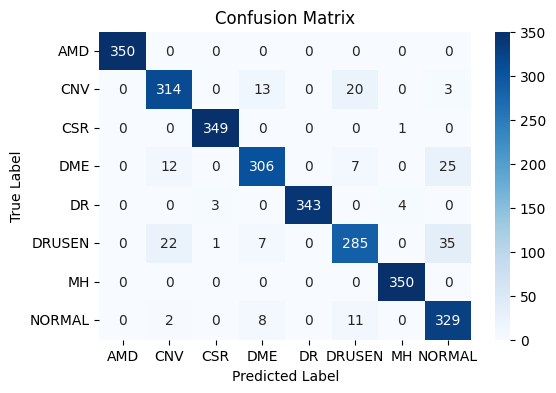

In [84]:
# Defining the number of classes:
num_classes = len(labels)

# Creating the confusion matrix:
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Visualizing the confusion matrix:
class_labels = ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL'] # Your class labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [85]:
# Initializing a dictionary that will hold the metrics values:
confusion_matrix_table = {'AMD': {'TP': None, 'FP': None, 'FN': None, 'TN': None, 'Precision': None, 'Recall': None, 'f1_score': None},
                          'CNV': {'TP': None, 'FP': None, 'FN': None, 'TN': None, 'Precision': None, 'Recall': None, 'f1_score': None},
                          'CSR': {'TP': None, 'FP': None, 'FN': None, 'TN': None, 'Precision': None, 'Recall': None, 'f1_score': None},
                          'DME': {'TP': None, 'FP': None, 'FN': None, 'TN': None, 'Precision': None, 'Recall': None, 'f1_score': None},
                          'DR': {'TP': None, 'FP': None, 'FN': None, 'TN': None, 'Precision': None, 'Recall': None, 'f1_score': None},
                          'DRUSEN': {'TP': None, 'FP': None, 'FN': None, 'TN': None, 'Precision': None, 'Recall': None, 'f1_score': None},
                          'MH': {'TP': None, 'FP': None, 'FN': None, 'TN': None, 'Precision': None, 'Recall': None, 'f1_score': None},
                          'NORMAL': {'TP': None, 'FP': None, 'FN': None, 'TN': None, 'Precision': None, 'Recall': None, 'f1_score': None}
                         }

# Getting the metrics for all the classes:
for class_index in range(0, len(labels)):
    class_name = class_labels[class_index]
    
    # Extracting TP, FP, FN and TN:
    TP = cm[class_index, class_index]
    FP = np.sum(cm[:, class_index]) - TP
    FN = np.sum(cm[class_index, :]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    # Populating the dictionary:
    confusion_matrix_table[class_name]['TP'] = TP
    confusion_matrix_table[class_name]['FP'] = FP
    confusion_matrix_table[class_name]['FN'] = FN
    confusion_matrix_table[class_name]['TN'] = TN
    
    # Calculating the precision, recall, and F1-score:
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Populating the dictionary:
    confusion_matrix_table[class_labels[class_index]]['Precision'] = round(precision, 2)
    confusion_matrix_table[class_name]['Recall'] = round(recall, 2)
    confusion_matrix_table[class_name]['f1_score'] = round(f1_score, 2)

# Creating the confusion matrix dataframe:
confusion_matrix_df = pd.DataFrame(confusion_matrix_table)
confusion_matrix_df

,AMD,CNV,CSR,DME,DR,DRUSEN,MH,NORMAL
TP,350.0,314.0,349.00,306.00,343.00,285.00,350.00,329.00
FP,0.0,36.0,4.00,28.00,0.00,38.00,5.00,63.00
FN,0.0,36.0,1.00,44.00,7.00,65.00,0.00,21.00
TN,2450.0,2414.0,2446.00,2422.00,2450.00,2412.00,2445.00,2387.00
Precision,1.0,0.9,0.99,0.92,1.00,0.88,0.99,0.84
Recall,1.0,0.9,1.00,0.87,0.98,0.81,1.00,0.94
f1_score,1.0,0.9,0.99,0.89,0.99,0.85,0.99,0.89


Looking at the f1_score, which is the mean of the Precision and Recall, we see a good result for each class; although for DRUSEN it is 85% but still considered a good score, however, the average across all labels is **93.75%**.

The amount of False Negative (FN) and False Positive (FP) predicted for each class is low, indicating a reliable model, but of course, it could be further improved.

**Visualizing the model performance**

Here's a visulization showing the accuracy VS val_accuracy, and the loss VS val_loss:

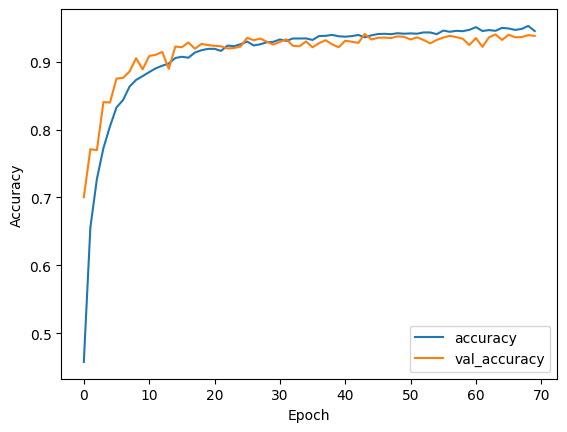

In [31]:
# Visualizing the accuracy:
acc_df = pd.DataFrame(fitting_information.history['accuracy'])
val_acc_df = pd.DataFrame(fitting_information.history['val_accuracy'])
acc_vis_df = acc_df.join(val_acc_df, lsuffix='_accuracy', rsuffix='_val_accuracy')

fig, ax = plt.subplots()
plt.plot(acc_vis_df)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(["accuracy", "val_accuracy"], loc="lower right")
plt.show()

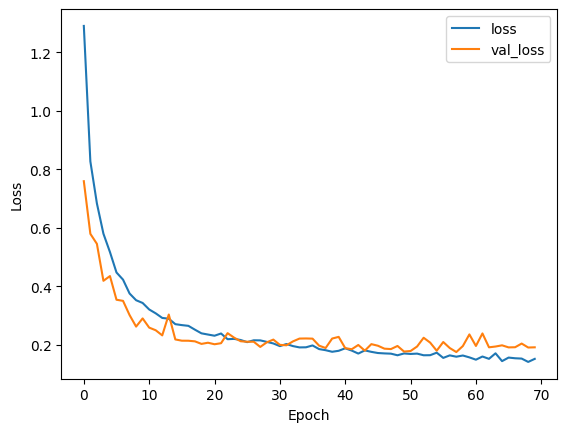

In [32]:
# Visualizing the loss:
loss_df = pd.DataFrame(fitting_information.history['loss'])
val_loss_df = pd.DataFrame(fitting_information.history['val_loss'])
loss_vis_df = loss_df.join(val_loss_df, lsuffix='_loss', rsuffix='_val_loss')

plt.plot(loss_vis_df)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(["loss", "val_loss"], loc="upper right")
plt.show()

**Testing the model through application**

In [33]:
# Image prediction function:
def predict_image(image, img_class):
    # Initialize the image labels:
    labels = ['AMD', 'CNV', 'DME', 'CSR', 'DR', 'DRUSEN', 'NORMAL', 'MH']

    # Initialize a dictionary that will hold the lables as keys and the prediction values as items:
    prediction_dict = {'AMD': None, 'CNV': None, 'DME': None, 'CSR': None, 'DR': None, 'DRUSEN': None, 'NORMAL': None, 'MH': None}

    # Expending the dimensions of the image to be predicted:
    image_dims = np.expand_dims(image, axis=0)
    print(f"Class of image passed for validation: {img_class}")

    # Predict the image's label/class:
    cnn_img_pred = cnn_model.predict(image_dims)

    # Update the dictionary with the predicted probabilities:
    for arr in cnn_img_pred:
        for idx in range(len(arr)):
            prediction_dict[labels[idx]] = arr[idx]

    # Return the key of the maximum probability:
    return max(prediction_dict, key=prediction_dict.get)

In [67]:
print(f"Predicted image class: {predict_image(X_validation[2000], 'DRUSEN')}")

Class of image passed for validation: DRUSEN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted image class: DRUSEN


#### **Conclusion**

The Gaussian Naive Bayes model that I created was more for learning purposes on how to use pure math working with numpy to create a prediction model; the accuracy was not the focal point in this section. The model could be certainly improved through advanced filtering processes, but that will take a lot of work which I can cover in another dedicated project.

When using deep learning, we can clearly conclude that it can deal efficiently with noisy data and can perform very well on both the training accuracy and the validation as well; by validation I mean images that are passed to the model to predict in which the model has not seen before.

Convolutional Neural Network was a right choice to use, however, the model can perform even better with the right parameters tweak, on the Image Data Generator, the number of convolutional layers, the number of batches, the dropout size, the activation function and the optimizer. As for the f1_score, since we are in the medical context, the model can be improved to focus more on the Recall even if the Precision diminished a bit. In some cases, it might be more important to correctly identify all cases of a rare disease (high Recall) even if it means some healthy patients get a False Positive.

Although the accuracy of the model is high with no overfitting or underfitting, this machine learning model should only be used to help doctors and scientists take decisions, in which they rely more on their expertise in the medical field, as AI models are not 100% accurate and can still hallucinate.